# 03 — Pre-flight checks: SRM and A/A validation

Two checks every experiment platform should run before anyone looks at the primary metric.

**SRM (Sample Ratio Mismatch).** Chi-square the assignment split against the intended ratio. A p-value below ~0.001 means randomization is broken at the platform level. If SRM fires, every downstream number is suspect because the comparison groups are no longer comparable. The fix is fixing the bug, not p-hacking around it.

**A/A test.** Run the same statistical machinery you'll use to analyze the real experiment, but on two groups drawn from the *same* population. The empirical Type I error rate should land near alpha. If it doesn't, there is a bug in the analysis code, an assumption violation, or a peeking habit. The 10,000-simulation A/A here is the standalone proof the test pipeline is correctly calibrated.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

from src import config
from src.io_utils import load_events
from src.preflight import check_srm, run_aa
from src.viz import pvalue_histogram

FIG_DIR = ROOT / 'reports' / 'figures'

## Load the experiment data

In [2]:
events = load_events(config.EXPERIMENT_EVENTS_PARQUET)
arm_counts = events['arm'].value_counts().to_dict()
print(f'arm counts: {arm_counts}')
print(f'total users: {len(events):,}')

arm counts: {'treatment': 25186, 'control': 24814}
total users: 50,000


## SRM chi-square

In [3]:
srm = check_srm({'control': arm_counts['control'], 'treatment': arm_counts['treatment']})
for k, v in srm.items():
    print(f'{k:>10}: {v}')
print()
if srm['verdict'] == 'pass':
    print('SRM check passed. Assignment ratio is within chance variation of 50/50.')
else:
    print('SRM ALARM. Assignment ratio deviates from 50/50 more than chance allows.')
    print('Stop. Do not analyze. Find the bug.')

      arms: ['control', 'treatment']
    counts: [24814, 25186]
    shares: [0.49628, 0.50372]
      chi2: 2.76768
    pvalue: 0.09618547799548627
   verdict: pass

SRM check passed. Assignment ratio is within chance variation of 50/50.


### What a real SRM looks like

To show the chi-square's teeth: simulate a 51/49 split (a 2-percentage-point bias). On 50k users this should be enough to flag.  

In [4]:
bad_srm = check_srm({'control': 25_500, 'treatment': 24_500})
print(f'simulated 51/49 split on 50k users')
print(f'  chi2 = {bad_srm["chi2"]:.2f}')
print(f'  pvalue = {bad_srm["pvalue"]:.6f}')
print(f'  verdict: {bad_srm["verdict"]}')

simulated 51/49 split on 50k users
  chi2 = 20.00
  pvalue = 0.000008
  verdict: alarm


## A/A test — 10,000 simulations

Both arms drawn from the same baseline. The two-proportion z-test is run on each pair. Empirical Type I rate is the share with p < alpha. **This is the single strongest demonstration that the analysis pipeline is correctly calibrated.**

In [5]:
baseline = config.baseline_completion_rate()
n_per_arm = (events.arm == 'control').sum()

aa = run_aa(n_per_arm=int(n_per_arm), baseline=float(baseline), n_sims=10_000, seed=config.SEED)

print(f'baseline rate:    {aa.baseline:.4f}')
print(f'n per arm:        {aa.n_per_arm:,}')
print(f'n simulations:    {aa.n_sims:,}')
print(f'alpha:            {aa.alpha}')
print(f'empirical FPR:    {aa.empirical_fpr:.4f}')

baseline rate:    0.0500
n per arm:        24,814
n simulations:    10,000
alpha:            0.05
empirical FPR:    0.0505


In [6]:
assert 0.04 <= aa.empirical_fpr <= 0.06, (
    f'A/A FPR drifted to {aa.empirical_fpr:.4f} (expected ~0.05). '
    'Something is wrong with the statistics pipeline.'
)
print(f'A/A calibration passes: empirical FPR {aa.empirical_fpr:.4f} is within [0.04, 0.06] of alpha=0.05.')

A/A calibration passes: empirical FPR 0.0505 is within [0.04, 0.06] of alpha=0.05.


### Under the null, p-values are uniform on [0, 1]

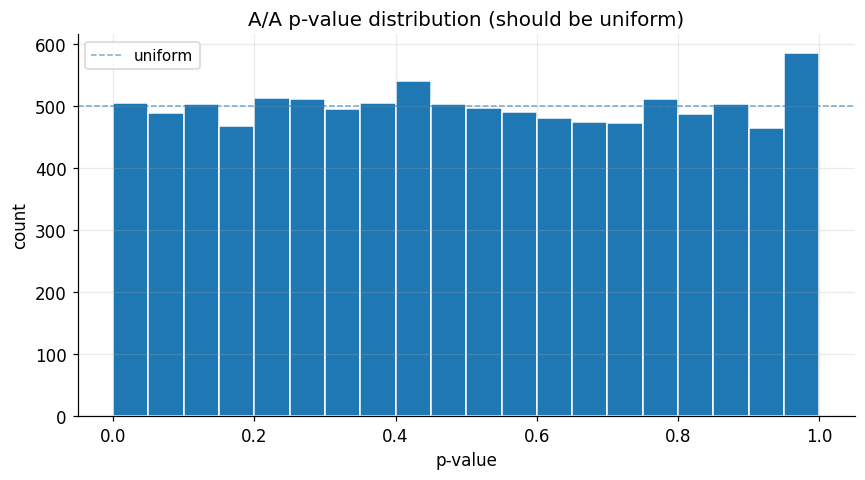

In [7]:
_ = pvalue_histogram(aa.pvalues, save_to=FIG_DIR / '03_aa_pvalue_uniform.png')

### Operational read

An A/A test takes a few minutes to run and catches an entire class of bugs that primary-metric analysis would miss. The cost of running it is small. The cost of skipping it is shipping the wrong launch decision and not knowing why.